In [1]:
pip install google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import torch
import numpy as np
import pandas as pd
import json
import time
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (RobertaForSequenceClassification,RobertaTokenizer)
from google import genai
from dotenv import load_dotenv
from data_loader import load_edos_data, TASK_A_ID2LABEL, TASK_B_ID2LABEL
DATA_DIR    = '../data/'
RESULTS_DIR = '../results/'
MODELS_DIR  = '../models/'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\Ashwin Nair\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
load_dotenv('../.env')
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
if not GEMINI_API_KEY:
    raise ValueError('GEMINI_API_KEY not found in .env file')
client = genai.Client(api_key=GEMINI_API_KEY)
print('Gemini client created successfully.')

Gemini client created successfully.


In [4]:
import time
time.sleep(60)  # wait 60 seconds to clear any per-minute rate limit
response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents="Reply with OK only."
)
print(f'Gemini API working: {response.text.strip()}')

Gemini API working: OK


In [5]:
def load_roberta(task: str):
    model_path = os.path.join(MODELS_DIR, f'roberta_task_{task}') ## Load the model from the specified path
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f'Model not found at {model_path}. '
            'Run Notebook 02 first to train and save the model.')
    tokenizer=RobertaTokenizer.from_pretrained('roberta-base')
    model=RobertaForSequenceClassification.from_pretrained(model_path)
    model.to(DEVICE)
    model.eval()
    print(f'Loaded RoBERTa Task {task} from {model_path}')
    return model, tokenizer
roberta_a, tokenizer_a = load_roberta('A')
roberta_b, tokenizer_b = load_roberta('B')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5737.45it/s]


Loaded RoBERTa Task A from ../models/roberta_task_A


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5435.77it/s]


Loaded RoBERTa Task B from ../models/roberta_task_B


In [6]:
def roberta_predict(text: str, model, tokenizer, id2label: dict) -> tuple:
    encoding = tokenizer( ## Encode the input text using the tokenizer
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad():
        outputs=model(**encoding)
        probs=torch.softmax(outputs.logits, dim=-1).squeeze()
    pred_id=torch.argmax(probs).item()
    confidence=probs[pred_id].item()
    label=id2label[pred_id]
    all_probs={id2label[i]: round(probs[i].item(), 4) for i in range(len(probs))}
    
    return label, confidence, all_probs

In [7]:
GEMINI_MODEL = "gemini-2.5-flash-lite"

# Different thresholds per task
# Task A (binary): higher threshold — RoBERTa confidence is naturally higher
# Task B (4-class): lower threshold — confidence split across 4 classes
CONFIDENCE_THRESHOLD_A = 0.80
CONFIDENCE_THRESHOLD_B = 0.60

TASK_A_PROMPT = """You are helping a sexism detection classifier correct uncertain predictions.

The classifier analysed this social media post but is NOT confident in its prediction.

Post: "{text}"

Classifier prediction: {prediction} (confidence: {confidence:.1%}) — LOW CONFIDENCE
Classifier probabilities: {probs}

The classifier is uncertain. Carefully review the post considering:
- Explicit sexist language (slurs, insults directed at women)
- Implicit sexism (stereotypes, gender role assumptions, sarcasm)
- Context and tone

Only override the classifier if you have clear evidence it is wrong.

Respond with ONLY one of these two labels (no explanation):
not sexist
sexist"""


TASK_B_PROMPT = """You are helping a sexism detection classifier correct uncertain predictions.

This post has been identified as sexist. The classifier is NOT confident about which category it belongs to.

Post: "{text}"

Classifier prediction: {prediction} (confidence: {confidence:.1%}) — LOW CONFIDENCE
Classifier probabilities: {probs}

Categories:
- threats — direct or indirect threats of violence or harm against women
- derogation — insults, slurs, or portraying women as inferior
- animosity — hostility, contempt, or hatred towards women or feminists
- prejudiced discussions — ideological claims about gender roles or women's place in society

Only override the classifier if you have clear evidence it is wrong.

Respond with ONLY one of these exact words or phrases (no explanation, no numbers, no punctuation):
threats
derogation
animosity
prejudiced discussions"""

In [8]:
# Maps short Gemini responses to full EDOS Task B labels
TASK_B_SHORT_TO_FULL = {
    'threats':                '1. threats, plans to harm and incitement',
    'threat':                 '1. threats, plans to harm and incitement',
    'derogation':             '2. derogation',
    'animosity':              '3. animosity',
    'animosty':               '3. animosity',  # common Gemini typo
    'prejudiced discussions': '4. prejudiced discussions',
    'prejudiced':             '4. prejudiced discussions',
}

def llm_refine(text: str, roberta_label: str, confidence: float,
               all_probs: dict, task: str, max_retries: int = 3):
    """
    Pass RoBERTa prediction to Gemini for refinement.
    Only called when RoBERTa confidence is below the task threshold.
    Returns the LLM's final label, or None if all retries fail.
    """
    if task == 'A':
        prompt       = TASK_A_PROMPT.format(
            text=text, prediction=roberta_label,
            confidence=confidence, probs=all_probs
        )
        valid_labels = {'not sexist', 'sexist'}
    else:
        prompt       = TASK_B_PROMPT.format(
            text=text, prediction=roberta_label,
            confidence=confidence, probs=all_probs
        )
        valid_labels = {
            '1. threats, plans to harm and incitement',
            '2. derogation',
            '3. animosity',
            '4. prejudiced discussions'
        }

    for attempt in range(max_retries):
        try:
            response  = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt
            )
            llm_label = response.text.strip().lower()

            # Exact match against full labels
            if llm_label in valid_labels:
                return llm_label

            # Task B — map short labels to full labels
            if task == 'B':
                if llm_label in TASK_B_SHORT_TO_FULL:
                    return TASK_B_SHORT_TO_FULL[llm_label]
                # Partial match fallback
                for short, full in TASK_B_SHORT_TO_FULL.items():
                    if short in llm_label:
                        return full

            # Task A — partial match fallback
            if task == 'A':
                for valid in valid_labels:
                    if valid in llm_label:
                        return valid

            print(f'  Unrecognised LLM response: "{llm_label}" — skipping sample')
            return None

        except Exception as e:
            if '429' in str(e):
                wait = 60 * (attempt + 1)
                print(f'  Rate limit — waiting {wait}s (retry {attempt+1}/{max_retries})')
                time.sleep(wait)
            elif attempt < max_retries - 1:
                time.sleep(5)
            else:
                print(f'  LLM call failed after {max_retries} attempts')

    return None

In [9]:
def run_baseline2(task: str, sample_size: int = None):
    """
    Baseline 2 pipeline with confidence-gated LLM refinement.
    Task A: LLM called when RoBERTa confidence < 0.80
    Task B: LLM called when RoBERTa confidence < 0.60
    High-confidence predictions use RoBERTa directly — no API call.
    """
    print(f'\n{"="*50}')
    print(f'Baseline 2 — RoBERTa + LLM Refiner — Task {task}')
    threshold = CONFIDENCE_THRESHOLD_A if task == 'A' else CONFIDENCE_THRESHOLD_B
    print(f'Confidence threshold: {threshold}')
    print(f'{"="*50}')

    _, _, test_df = load_edos_data(DATA_DIR, task=task)

    if sample_size:
        test_df = test_df.head(sample_size)
        print(f'Running on {sample_size} samples (test mode)')
    else:
        print(f'Running on full test set ({len(test_df)} samples)')

    if task == 'A':
        model, tokenizer, id2label = roberta_a, tokenizer_a, TASK_A_ID2LABEL
    else:
        model, tokenizer, id2label = roberta_b, tokenizer_b, TASK_B_ID2LABEL

    # Load checkpoint if available
    checkpoint_path = os.path.join(RESULTS_DIR, f'task_{task}_baseline2_checkpoint.json')
    if os.path.exists(checkpoint_path) and not sample_size:
        with open(checkpoint_path, 'r') as f:
            checkpoint = json.load(f)
        true_labels    = checkpoint['true_labels']
        roberta_labels = checkpoint['roberta_labels']
        llm_labels     = checkpoint['llm_labels']
        start_idx      = len(true_labels)
        print(f'Resuming from checkpoint at index {start_idx}/{len(test_df)}')
    else:
        true_labels    = []
        roberta_labels = []
        llm_labels     = []
        start_idx      = 0

    llm_called   = 0
    llm_skipped  = 0
    llm_override = 0

    print('\nRunning pipeline...')
    for i, (_, row) in enumerate(test_df.iterrows()):
        if i < start_idx:
            continue

        if i % 100 == 0:
            print(f'  Progress: {i}/{len(test_df)} | LLM called: {llm_called} | Skipped: {llm_skipped}')

        text       = row['text']
        true_label = row['label']

        # Step 1: RoBERTa prediction
        r_label, r_conf, r_probs = roberta_predict(text, model, tokenizer, id2label)

        # Step 2: Confidence-gated LLM refinement
        if r_conf < threshold:
            llm_called += 1
            llm_label = llm_refine(text, r_label, r_conf, r_probs, task)

            if llm_label is None:
                # LLM failed — skip sample
                llm_skipped += 1
                continue

            if llm_label != r_label.lower():
                llm_override += 1

            time.sleep(2)
        else:
            # RoBERTa confident — use directly, no API call
            llm_label = r_label.lower()

        true_labels.append(true_label)
        roberta_labels.append(r_label.lower())
        llm_labels.append(llm_label)

        # Save checkpoint every 100 samples
        if not sample_size and i % 100 == 0:
            with open(checkpoint_path, 'w') as f:
                json.dump({
                    'true_labels':    true_labels,
                    'roberta_labels': roberta_labels,
                    'llm_labels':     llm_labels
                }, f)

    # Final checkpoint
    if not sample_size:
        with open(checkpoint_path, 'w') as f:
            json.dump({
                'true_labels':    true_labels,
                'roberta_labels': roberta_labels,
                'llm_labels':     llm_labels
            }, f)
        print('Final checkpoint saved.')

    print(f'\nPipeline complete:')
    print(f'  Total samples:              {len(true_labels)}')
    print(f'  LLM called (low conf):      {llm_called}')
    print(f'  LLM skipped (failed):       {llm_skipped}')
    print(f'  LLM overrode RoBERTa:       {llm_override}')
    print(f'  RoBERTa used directly:      {len(true_labels) - llm_called + llm_skipped}')

    return true_labels, roberta_labels, llm_labels

In [10]:
def evaluate_baseline2(true_labels, roberta_labels, llm_labels, task: str):
    """Compare RoBERTa-only vs RoBERTa+LLM performance."""

    if task == 'A':
        label_names = ['not sexist', 'sexist']
    else:
        label_names = [
            '1. threats, plans to harm and incitement',
            '2. derogation',
            '3. animosity',
            '4. prejudiced discussions'
        ]

    print(f'\n{"="*50}')
    print(f'Evaluation — Task {task}')
    print(f'{"="*50}')

    print('\n--- RoBERTa Only ---')
    r_report = classification_report(
        true_labels, roberta_labels,
        labels=label_names, digits=4, zero_division=0
    )
    print(r_report)

    print('\n--- RoBERTa + LLM Refiner (confidence-gated) ---')
    llm_report = classification_report(
        true_labels, llm_labels,
        labels=label_names, digits=4, zero_division=0
    )
    print(llm_report)

    # Save reports
    report_path = os.path.join(RESULTS_DIR, f'task_{task}_baseline2_results.txt')
    with open(report_path, 'w') as f:
        f.write(f'Baseline 2 — RoBERTa + LLM Refiner (confidence-gated) — Task {task}\n\n')
        threshold = CONFIDENCE_THRESHOLD_A if task == 'A' else CONFIDENCE_THRESHOLD_B
        f.write(f'Confidence threshold: {threshold}\n\n')
        f.write('RoBERTa Only:\n')
        f.write(r_report)
        f.write('\nRoBERTa + LLM Refiner:\n')
        f.write(llm_report)
    print(f'Report saved to {report_path}')

    # Side by side confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm_r = confusion_matrix(true_labels, roberta_labels, labels=label_names)
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_title(f'RoBERTa Only — Task {task}', fontsize=13)
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=30)

    cm_llm = confusion_matrix(true_labels, llm_labels, labels=label_names)
    sns.heatmap(cm_llm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_title(f'RoBERTa + LLM (confidence-gated) — Task {task}', fontsize=13)
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle(f'Baseline 2 Confusion Matrices — Task {task}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    cm_path = os.path.join(RESULTS_DIR, f'task_{task}_baseline2_confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to {cm_path}')

    # Summary
    _, _, r_f1, _   = precision_recall_fscore_support(
        true_labels, roberta_labels, average='macro', zero_division=0
    )
    _, _, llm_f1, _ = precision_recall_fscore_support(
        true_labels, llm_labels, average='macro', zero_division=0
    )
    delta = llm_f1 - r_f1

    print(f'\nMacro F1 Comparison — Task {task}:')
    print(f'  RoBERTa only:              {r_f1:.4f}')
    print(f'  RoBERTa + LLM (gated):     {llm_f1:.4f}')
    print(f'  Delta:                     {delta:+.4f} ({"improvement" if delta > 0 else "regression"})')

    return {
        'roberta_f1': r_f1,
        'llm_f1':     llm_f1,
        'delta':      delta
    }

In [11]:
# Delete old checkpoints first to start fresh
for task in ['A', 'B']:
    cp = os.path.join(RESULTS_DIR, f'task_{task}_baseline2_checkpoint.json')
    if os.path.exists(cp):
        os.remove(cp)
        print(f'Deleted old checkpoint: {cp}')

true_a_test, rob_a_test, llm_a_test = run_baseline2(task='A', sample_size=20)

print('\nSample predictions:')
for true, rob, llm in zip(true_a_test, rob_a_test, llm_a_test):
    match = '✓' if llm == true else '✗'
    called = '(LLM)' if rob != llm else '(RoBERTa)'
    print(f'  {match} True: {true:<15} RoBERTa: {rob:<15} Final: {llm:<15} {called}')

Deleted old checkpoint: ../results/task_A_baseline2_checkpoint.json

Baseline 2 — RoBERTa + LLM Refiner — Task A
Confidence threshold: 0.8
Running on 20 samples (test mode)

Running pipeline...
  Progress: 0/20 | LLM called: 0 | Skipped: 0

Pipeline complete:
  Total samples:              20
  LLM called (low conf):      1
  LLM skipped (failed):       0
  LLM overrode RoBERTa:       1
  RoBERTa used directly:      19

Sample predictions:
  ✓ True: not sexist      RoBERTa: not sexist      Final: not sexist      (RoBERTa)
  ✓ True: sexist          RoBERTa: sexist          Final: sexist          (RoBERTa)
  ✓ True: not sexist      RoBERTa: not sexist      Final: not sexist      (RoBERTa)
  ✓ True: sexist          RoBERTa: sexist          Final: sexist          (RoBERTa)
  ✓ True: sexist          RoBERTa: sexist          Final: sexist          (RoBERTa)
  ✓ True: not sexist      RoBERTa: not sexist      Final: not sexist      (RoBERTa)
  ✓ True: not sexist      RoBERTa: not sexist      Fi


Baseline 2 — RoBERTa + LLM Refiner — Task A
Confidence threshold: 0.8
Running on full test set (4000 samples)

Running pipeline...
  Progress: 0/4000 | LLM called: 0 | Skipped: 0
  Progress: 100/4000 | LLM called: 3 | Skipped: 0
  Progress: 200/4000 | LLM called: 8 | Skipped: 0
  Progress: 300/4000 | LLM called: 12 | Skipped: 0
  Progress: 400/4000 | LLM called: 18 | Skipped: 0
  Progress: 500/4000 | LLM called: 21 | Skipped: 0
  Progress: 600/4000 | LLM called: 26 | Skipped: 0
  Progress: 700/4000 | LLM called: 31 | Skipped: 0
  Progress: 800/4000 | LLM called: 37 | Skipped: 0
  Progress: 900/4000 | LLM called: 40 | Skipped: 0
  Progress: 1000/4000 | LLM called: 45 | Skipped: 0
  Progress: 1100/4000 | LLM called: 55 | Skipped: 0
  Progress: 1200/4000 | LLM called: 60 | Skipped: 0
  Progress: 1300/4000 | LLM called: 69 | Skipped: 0
  Progress: 1400/4000 | LLM called: 76 | Skipped: 0
  Progress: 1500/4000 | LLM called: 83 | Skipped: 0
  Progress: 1600/4000 | LLM called: 85 | Skipped: 0

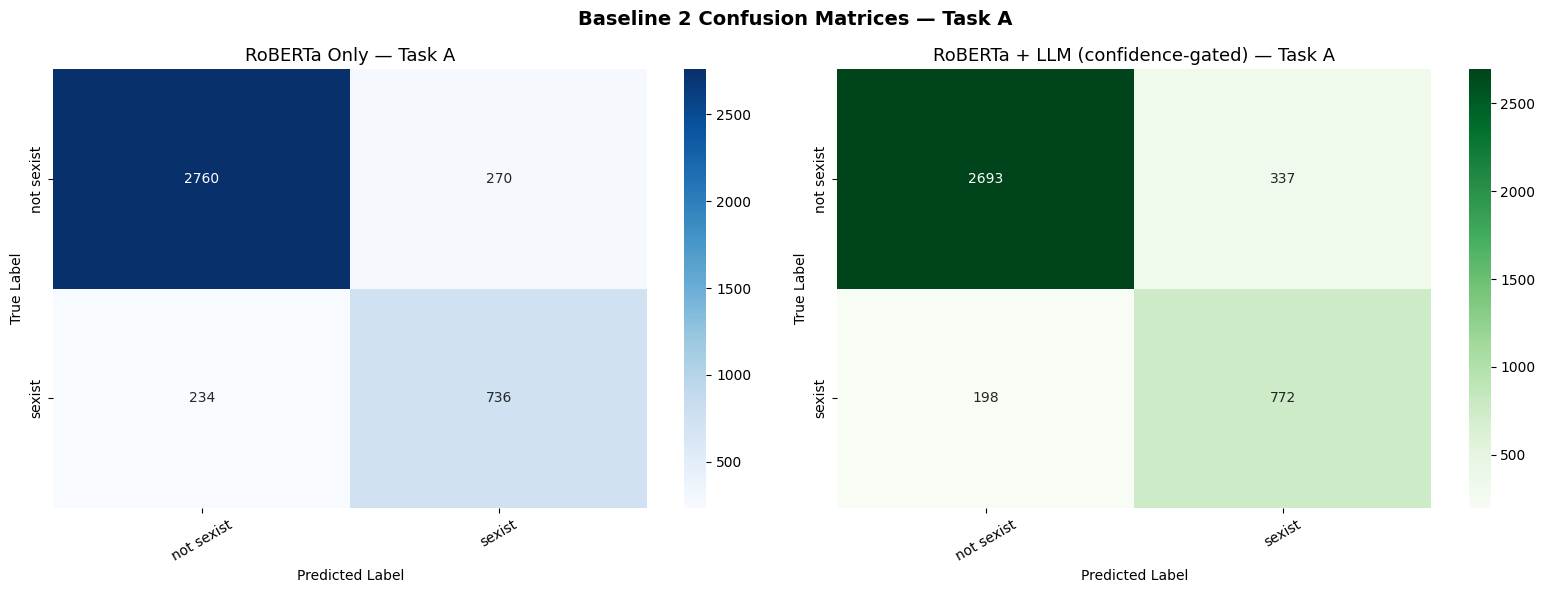

Confusion matrix saved to ../results/task_A_baseline2_confusion_matrix.png

Macro F1 Comparison — Task A:
  RoBERTa only:              0.8306
  RoBERTa + LLM (gated):     0.8262
  Delta:                     -0.0045 (regression)


In [12]:
true_a, roberta_a_preds, llm_a_preds = run_baseline2(task='A')
results_a = evaluate_baseline2(true_a, roberta_a_preds, llm_a_preds, task='A')


Baseline 2 — RoBERTa + LLM Refiner — Task B
Confidence threshold: 0.6
Running on full test set (970 samples)

Running pipeline...
  Progress: 0/970 | LLM called: 0 | Skipped: 0
  Progress: 100/970 | LLM called: 40 | Skipped: 0
  Progress: 200/970 | LLM called: 72 | Skipped: 0
  Progress: 300/970 | LLM called: 107 | Skipped: 0
  Progress: 400/970 | LLM called: 137 | Skipped: 0
  Progress: 500/970 | LLM called: 179 | Skipped: 0
  Progress: 600/970 | LLM called: 212 | Skipped: 0
  Progress: 700/970 | LLM called: 242 | Skipped: 0
  Progress: 800/970 | LLM called: 281 | Skipped: 0
  Progress: 900/970 | LLM called: 327 | Skipped: 0
Final checkpoint saved.

Pipeline complete:
  Total samples:              970
  LLM called (low conf):      353
  LLM skipped (failed):       0
  LLM overrode RoBERTa:       144
  RoBERTa used directly:      617

Evaluation — Task B

--- RoBERTa Only ---
                                          precision    recall  f1-score   support

1. threats, plans to harm a

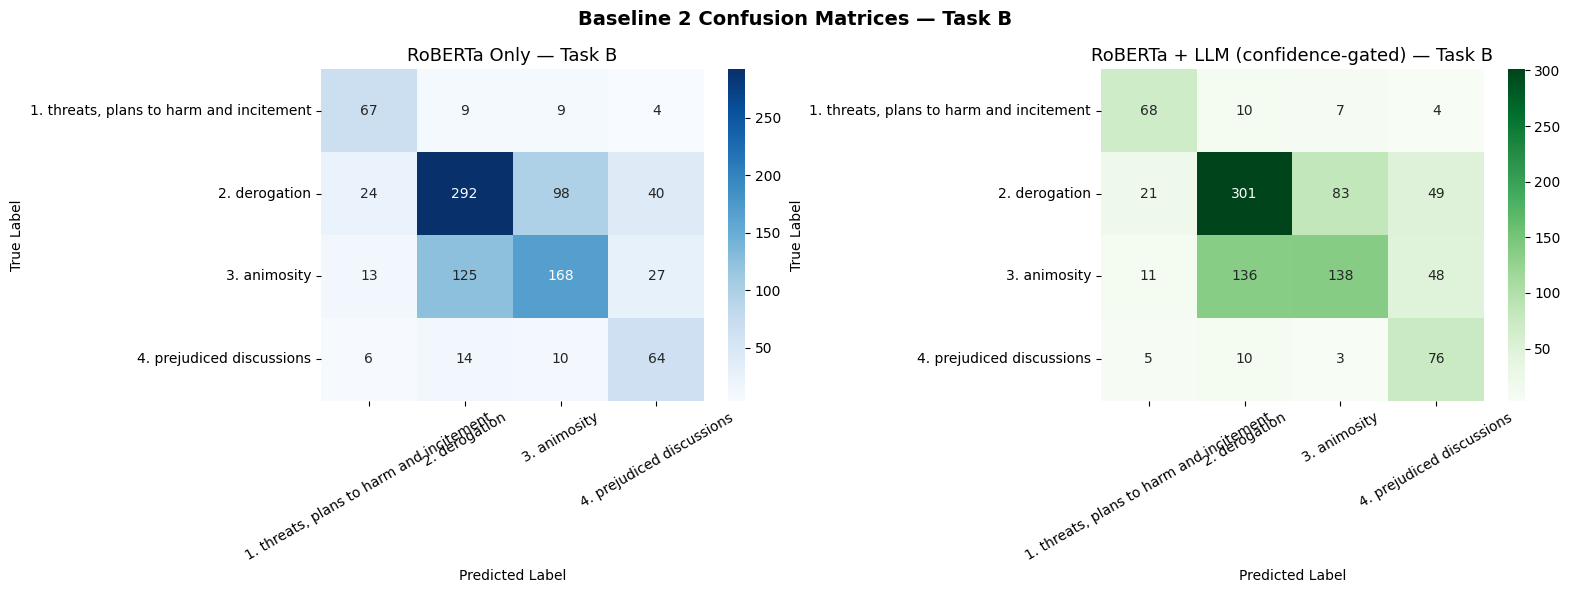

Confusion matrix saved to ../results/task_B_baseline2_confusion_matrix.png

Macro F1 Comparison — Task B:
  RoBERTa only:              0.6073
  RoBERTa + LLM (gated):     0.6030
  Delta:                     -0.0043 (regression)


In [13]:
true_b, roberta_b_preds, llm_b_preds = run_baseline2(task='B')
results_b = evaluate_baseline2(true_b, roberta_b_preds, llm_b_preds, task='B')